In [1]:
library(mlr)
library(tidyverse)
library(parallel)
library(parallelMap)

Loading required package: ParamHelpers

── Attaching core tidyverse packages ────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.2
✔ ggplot2   3.5.2     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.1.0     
── Conflicts ──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [2]:
data(Ozone, package = 'mlbench')

In [3]:
ozonetib<-as_tibble(Ozone)
ozonetib

V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13
<fct>,<fct>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,1,4,3,5480,8,20,NA,NA,5000,-15,30.56,200
1,2,5,3,5660,6,NA,38,NA,NA,-14,NA,300
1,3,6,3,5710,4,28,40,NA,2693,-25,47.66,250
1,4,7,5,5700,3,37,45,NA,590,-24,55.04,100
1,5,1,5,5760,3,51,54,45.32,1450,25,57.02,60
1,6,2,6,5720,4,69,35,49.64,1568,15,53.78,60
1,7,3,4,5790,6,19,45,46.40,2631,-33,54.14,100
1,8,4,4,5790,3,25,55,52.70,554,-28,64.76,250
1,9,5,6,5700,3,73,41,48.02,2083,23,52.52,120


In [4]:
names(ozonetib)<-c(
    'Month',
    'Date',
    'Day',
    'Ozone',
    'Press_height',
    'Wind',
    'Humid',
    'Temp_Sand',
    'Temp_Monte',
    'Inv_height',
    'Press_grad',
    'Inv_temp',
    'Visib'
)

In [5]:
ozonetib

Month,Date,Day,Ozone,Press_height,Wind,Humid,Temp_Sand,Temp_Monte,Inv_height,Press_grad,Inv_temp,Visib
<fct>,<fct>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,1,4,3,5480,8,20,NA,NA,5000,-15,30.56,200
1,2,5,3,5660,6,NA,38,NA,NA,-14,NA,300
1,3,6,3,5710,4,28,40,NA,2693,-25,47.66,250
1,4,7,5,5700,3,37,45,NA,590,-24,55.04,100
1,5,1,5,5760,3,51,54,45.32,1450,25,57.02,60
1,6,2,6,5720,4,69,35,49.64,1568,15,53.78,60
1,7,3,4,5790,6,19,45,46.40,2631,-33,54.14,100
1,8,4,4,5790,3,25,55,52.70,554,-28,64.76,250
1,9,5,6,5700,3,73,41,48.02,2083,23,52.52,120


In [6]:
map_dbl(ozonetib, ~sum(is.na(.)))

Month         Date          Day        Ozone Press_height         Wind 
           0            0            0            5           12            0 
       Humid    Temp_Sand   Temp_Monte   Inv_height   Press_grad     Inv_temp 
          15            2          139           15            1           14 
       Visib 
           0

In [7]:
a<-mutate_all(ozonetib,as.numeric)

In [8]:
ozoneclean<-a %>% filter(is.na(Ozone) == FALSE)

In [9]:
ozoneuntidy<-gather(ozoneclean,key = 'Variable',value = 'Value', -Ozone)
ozoneuntidy

Ozone,Variable,Value
<dbl>,<chr>,<dbl>
3,Month,1
3,Month,1
3,Month,1
5,Month,1
5,Month,1
6,Month,1
4,Month,1
4,Month,1
6,Month,1


`geom_smooth()` using method = 'loess' and formula = 'y ~ x'
Warning message:
“Removed 196 rows containing non-finite outside the scale range (`stat_smooth()`).”
`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 196 rows containing non-finite outside the scale range (`stat_smooth()`).”
Warning message:
“Removed 196 rows containing missing values or values outside the scale range (`geom_point()`).”
Saving 6.67 x 6.67 in image
`geom_smooth()` using method = 'loess' and formula = 'y ~ x'
Warning message:
“Removed 196 rows containing non-finite outside the scale range (`stat_smooth()`).”
`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 196 rows containing non-finite outside the scale range (`stat_smooth()`).”
Warning message:
“Removed 196 rows containing missing values or values outside the scale range (`geom_point()`).”


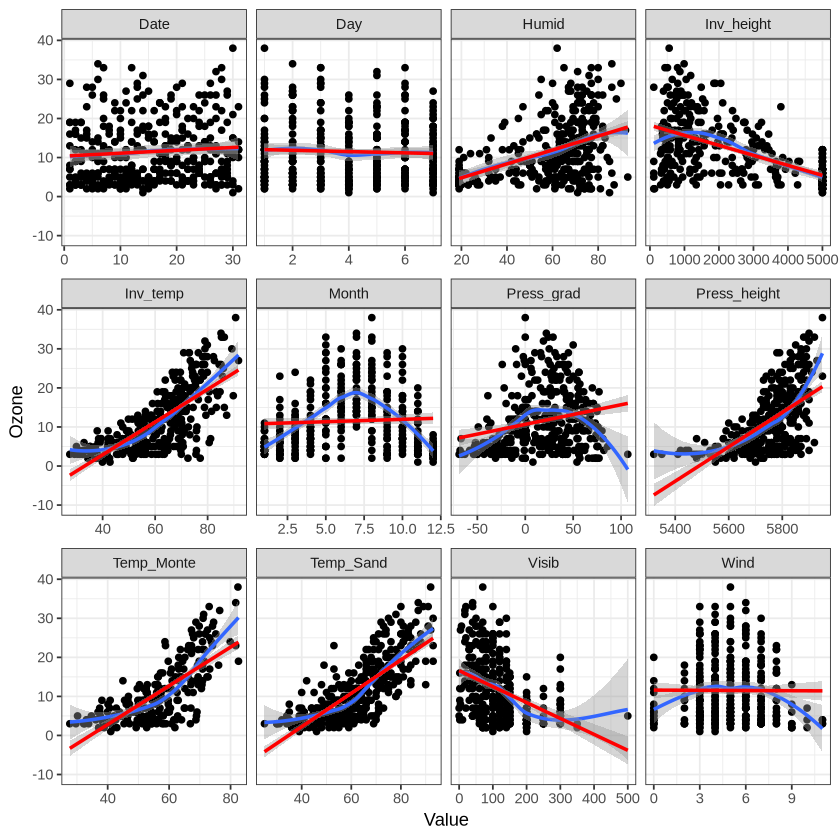

In [10]:

(
    ggplot(ozoneuntidy,aes(Value,Ozone)) + 
    facet_wrap(~Variable, scale = 'free_x') +
    geom_point() + 
    theme_bw() + 
    geom_smooth() + 
    geom_smooth(method = 'lm', col='red')
)

#puede usar gam!
ggsave('ozone.png')

In [11]:
?imputations

imputations {mlr},R Documentation
const,(any) Constant valued use for imputation.
multiplier,(numeric(1)) Value that stored minimum or maximum is multiplied with when imputation is done.
min,"(numeric(1)) Lower bound for uniform distribution. If NA (default), it will be estimated from the data."
max,"(numeric(1)) Upper bound for uniform distribution. If NA (default), it will be estimated from the data."
mu,(numeric(1)) Mean of normal distribution. If missing it will be estimated from the data.
sd,(numeric(1)) Standard deviation of normal distribution. If missing it will be estimated from the data.
breaks,"(numeric(1)) Number of breaks to use in graphics::hist. If missing, defaults to auto-detection via “Sturges”."
use.mids,"(logical(1)) If x is numeric and a histogram is used, impute with bin mids (default) or instead draw uniformly distributed samples within bin range."
learner,(Learner | character(1)) Supervised learner. Its predictions will be used for imputations. If you pass a string the learner will be created via makeLearner. Note that the target column is not available for this operation.
features,(character) Features to use in learner for prediction. Default is NULL which uses all available features except the target column of the original task.


#split the dataset into cases 
#decide on a regression algorithm to predict what the missing values would have been!

#if categorical we choose classification algorithm
#if numerical we choose regression algorithm

que interesante logistic regression no funciona por los mising values!

#missing value imputation

likelihood of a missing value depends on the value itself. porque el salario es bajo!

buenos

mcar
mar

y

malos
mnar


In [12]:
imputemethod<-imputeLearner('regr.rpart')

In [13]:
imputemethod

$learn
function (data, target, col, learner, features) 
{
    constructor = getTaskConstructorForLearner(learner)
    if (is.null(features)) {
        features = setdiff(names(data), target)
    }
    else {
        not.ok = which(features %nin% names(data))
        if (length(not.ok)) {
            stopf("Features for imputation not found in data: '%s'", 
                collapse(features[not.ok]))
        }
        not.ok = which.first(target %in% features)
        if (length(not.ok)) {
            stopf("Target column used as feature for imputation: '%s'", 
                target[not.ok])
        }
        if (col %nin% features) {
            features = c(col, features)
        }
    }
    impute.feats = setdiff(features, col)
    if (anyMissing(data[impute.feats]) && !hasLearnerProperties(learner, 
        "missings")) {
        has.na = vlapply(data[impute.feats], anyMissing)
        wrong.feats = clipString(collapse(colnames(data[impute.feats])[has.na], 
            ", "), 50L)


In [14]:
ozoneclean

Month,Date,Day,Ozone,Press_height,Wind,Humid,Temp_Sand,Temp_Monte,Inv_height,Press_grad,Inv_temp,Visib
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,1,4,3,5480,8,20,NA,NA,5000,-15,30.56,200
1,2,5,3,5660,6,NA,38,NA,NA,-14,NA,300
1,3,6,3,5710,4,28,40,NA,2693,-25,47.66,250
1,4,7,5,5700,3,37,45,NA,590,-24,55.04,100
1,5,1,5,5760,3,51,54,45.32,1450,25,57.02,60
1,6,2,6,5720,4,69,35,49.64,1568,15,53.78,60
1,7,3,4,5790,6,19,45,46.40,2631,-33,54.14,100
1,8,4,4,5790,3,25,55,52.70,554,-28,64.76,250
1,9,5,6,5700,3,73,41,48.02,2083,23,52.52,120


In [15]:
ozoneimp<-impute(as.data.frame(ozoneclean), classes = list(numeric = imputemethod))

In [16]:
ozoneimp$data

Month,Date,Day,Ozone,Press_height,Wind,Humid,Temp_Sand,Temp_Monte,Inv_height,Press_grad,Inv_temp,Visib
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,1,4,3,5480,8,20.00000,33,33.98000,5000.000,-15,30.56000,200
1,2,5,3,5660,6,31.00000,38,51.27180,4960.907,-14,38.24255,300
1,3,6,3,5710,4,28.00000,40,51.27180,2693.000,-25,47.66000,250
1,4,7,5,5700,3,37.00000,45,51.27180,590.000,-24,55.04000,100
1,5,1,5,5760,3,51.00000,54,45.32000,1450.000,25,57.02000,60
1,6,2,6,5720,4,69.00000,35,49.64000,1568.000,15,53.78000,60
1,7,3,4,5790,6,19.00000,45,46.40000,2631.000,-33,54.14000,100
1,8,4,4,5790,3,25.00000,55,52.70000,554.000,-28,64.76000,250
1,9,5,6,5700,3,73.00000,41,48.02000,2083.000,23,52.52000,120


In [17]:
ozonetask<-makeRegrTask(data = ozoneimp$data, target = 'Ozone')

In [18]:
#no metio el impute en la cross validation!

In [19]:
lin<-makeLearner('regr.lm')

#correlation is continuous 

predictor and outcome are continuous!

anova when the predictor is categorical and the output is continuous
#number of features we drop is an hyperparameter!
#feature addition!

#filter methods y wrapper methods!

In [20]:
listFilterMethods()

id,package,desc
<chr>,<chr>,<chr>
anova.test,,ANOVA Test for binary and multiclass classification tasks
auc,,AUC filter for binary classification tasks
carscore,care,CAR scores
FSelector_chi.squared,FSelector,Chi-squared statistic of independence between feature and target
FSelector_gain.ratio,FSelector,Entropy-based gain ratio between feature and target
FSelector_information.gain,FSelector,Entropy-based information gain between feature and target
FSelector_oneR,FSelector,oneR association rule
FSelector_relief,FSelector,RELIEF algorithm
FSelector_symmetrical.uncertainty,FSelector,Entropy-based symmetrical uncertainty between feature and target


In [21]:
filtervals<-generateFilterValuesData(ozonetask, method = 'linear.correlation')
filtervals

FilterValues:
Task: ozoneimp$data
            name    type             filter      value
          <char>  <char>             <fctr>      <num>
 1:    Temp_Sand numeric linear.correlation 0.76977674
 2:   Temp_Monte numeric linear.correlation 0.74159034
 3:     Inv_temp numeric linear.correlation 0.72712691
 4: Press_height numeric linear.correlation 0.58752354
 5:   Inv_height numeric linear.correlation 0.57563391
 6:        Humid numeric linear.correlation 0.45148094
 7:        Visib numeric linear.correlation 0.41471463
 8:   Press_grad numeric linear.correlation 0.23331823
 9:         Date numeric linear.correlation 0.08205094
10:        Month numeric linear.correlation 0.05371420
11:          Day numeric linear.correlation 0.04151444
12:         Wind numeric linear.correlation 0.00468138

In [22]:
filtervals$data

name,type,filter,value
<chr>,<chr>,<fct>,<dbl>
Month,numeric,linear.correlation,0.05371420
Date,numeric,linear.correlation,0.08205094
Day,numeric,linear.correlation,0.04151444
Press_height,numeric,linear.correlation,0.58752354
Wind,numeric,linear.correlation,0.00468138
Humid,numeric,linear.correlation,0.45148094
Temp_Sand,numeric,linear.correlation,0.76977674
Temp_Monte,numeric,linear.correlation,0.74159034
Inv_height,numeric,linear.correlation,0.57563391


Saving 6.67 x 6.67 in image


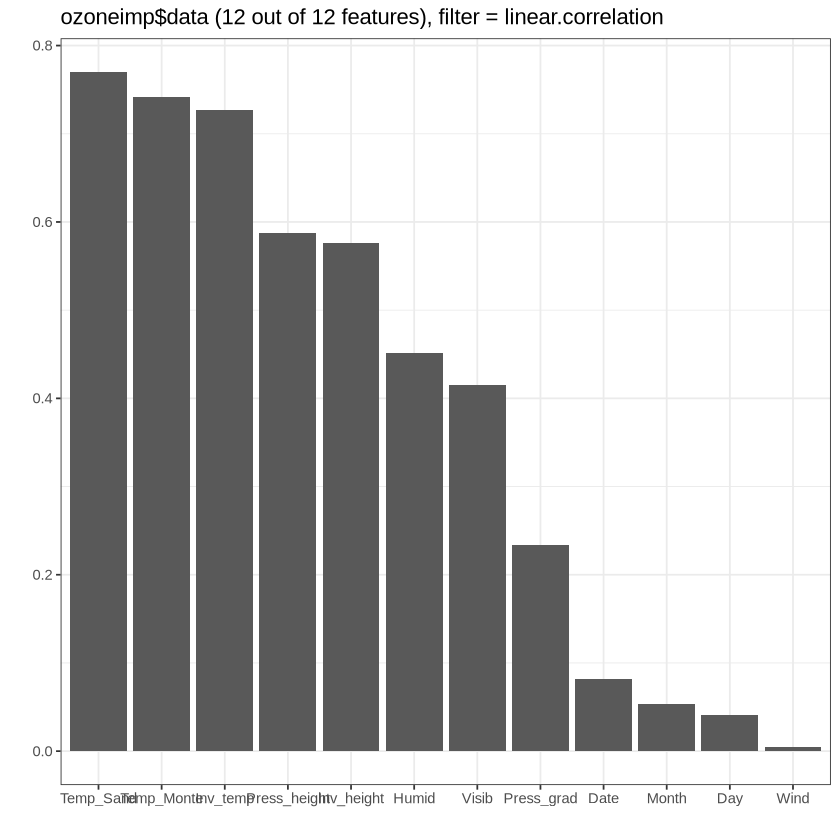

In [23]:
plotFilterValues(filtervals) + theme_bw()
ggsave('correlation.png')

In [24]:
#ozonefilttask<-filterFeatures(ozonetask, fval = filtervals, perc = 0.75)
#ozonefilttask

In [25]:
#ozonefilttask<-filterFeatures(ozonetask, fval = filtervals, threshold = 0.2)
#ozonefilttask

In [26]:
filterwrapper<-makeFilterWrapper(
    learner = lin, 
    fw.method = 'linear.correlation'
)

filterwrapper

Learner regr.lm.filtered from package stats
Type: regr
Name: ; Short name: 
Class: FilterWrapper
Properties: numerics,factors,weights,se
Predict-Type: response
Hyperparameters: 


In [27]:
lmparamspace<-makeParamSet(
    makeIntegerParam('fw.abs', lower = 1, upper = 12)
)
lmparamspace

          Type len Def  Constr Req Tunable Trafo
fw.abs integer   -   - 1 to 12   -    TRUE     -

In [28]:
gridsearch<-makeTuneControlGrid()

In [29]:
#aqui tienes una validacion de 10

In [30]:
kfold<-makeResampleDesc('CV', iters=10)

In [31]:
#que tantos parametros se necesitan y cuales?
tunedfeats<-tuneParams(
    filterwrapper, 
    task = ozonetask, 
    resampling = kfold,
    control = gridsearch,
    par.set = lmparamspace
)

#se divide el spacio y tienes datos que se usan para evaluar el modelo


[Tune] Started tuning learner regr.lm.filtered for parameter set:

          Type len Def  Constr Req Tunable Trafo
fw.abs integer   -   - 1 to 12   -    TRUE     -

With control class: TuneControlGrid

Imputation value: Inf

[Tune-x] 1: fw.abs=1

[Tune-y] 1: mse.test.mean=25.7391431; time: 0.0 min

[Tune-x] 2: fw.abs=2

[Tune-y] 2: mse.test.mean=25.2502722; time: 0.0 min

[Tune-x] 3: fw.abs=3

[Tune-y] 3: mse.test.mean=24.9625749; time: 0.0 min

[Tune-x] 4: fw.abs=5

[Tune-y] 4: mse.test.mean=22.5747136; time: 0.0 min

[Tune-x] 5: fw.abs=6

[Tune-y] 5: mse.test.mean=21.0192013; time: 0.0 min

[Tune-x] 6: fw.abs=7

[Tune-y] 6: mse.test.mean=20.9840531; time: 0.0 min

[Tune-x] 7: fw.abs=8

[Tune-y] 7: mse.test.mean=21.1376605; time: 0.0 min

[Tune-x] 8: fw.abs=10

[Tune-y] 8: mse.test.mean=20.9204582; time: 0.0 min

[Tune-x] 9: fw.abs=11

[Tune-y] 9: mse.test.mean=20.8454392; time: 0.0 min

[Tune-x] 10: fw.abs=12

[Tune-y] 10: mse.test.mean=20.9080414; time: 0.0 min

[Tune] Result: fw.a

In [32]:
tunedfeats

Tune result:
Op. pars: fw.abs=11
mse.test.mean=20.8454392

In [33]:
getParamSet(filterwrapper)

                      Type len    Def                                   Constr
fw.method         discrete   -      - anova.test,auc,carscore,cforest.impor...
fw.base.methods   discrete   -      - anova.test,auc,carscore,cforest.impor...
fw.perc            numeric   -      -                                   0 to 1
fw.abs             integer   -      -                                 0 to Inf
fw.threshold       numeric   -      -                              -Inf to Inf
fw.fun            function   -      -                                        -
fw.fun.args        untyped   - <NULL>                                        -
fw.mandatory.feat  untyped   -      -                                        -
tol                numeric   -  1e-07                                 0 to Inf
singular.ok        logical   -   TRUE                                        -
                  Req Tunable Trafo
fw.method           -    TRUE     -
fw.base.methods     -    TRUE     -
fw.perc             -  

In [34]:
?measures

measures {mlr},R Documentation
truth,(factor) Vector of the true class.
response,(factor) Vector of the predicted class.
probabilities,"(numeric | matrix) a) For purely binary classification measures: The predicted probabilities for the positive class as a numeric vector. b) For multiclass classification measures: The predicted probabilities for all classes, always as a numeric matrix, where columns are named with class labels."
negative,(character(1)) The name of the negative class.
positive,(character(1)) The name of the positive class.


In [35]:
measureMSE

function (truth, response) 
{
    mean((response - truth)^2)
}
<bytecode: 0x592d8c95d110>
<environment: namespace:mlr>

In [36]:
unlist(tunedfeats$x)

fw.abs 
    11

In [37]:
filteredtask<-filterFeatures(ozonetask, fval = filtervals, abs = unlist(tunedfeats$x))
filteredtask

Supervised task: ozoneimp$data
Type: regr
Target: Ozone
Observations: 361
Features:
   numerics     factors     ordered functionals 
         11           0           0           0 
Missings: FALSE
Has weights: FALSE
Has blocking: FALSE
Has coordinates: FALSE

In [38]:
model<-train(lin, filteredtask)
model

#tecnicamente 

Model for learner.id=regr.lm; learner.class=regr.lm
Trained on: task.id = ozoneimp$data; obs = 361; features = 11
Hyperparameters: 

In [39]:
featselcontrol<-makeFeatSelControlSequential(method = 'sfbs')

In [40]:
selfeat<-selectFeatures(
    learner = lin, 
    task = ozonetask, 
    resampling = kfold, 
    control = featselcontrol
)

[FeatSel] Started selecting features for learner 'regr.lm'

With control class: FeatSelControlSequential

Imputation value: Inf

[FeatSel-x] 1: 111111111111 (12 bits)

[FeatSel-y] 1: mse.test.mean=20.6185584; time: 0.0 min

[FeatSel-x] 2: 011111111111 (11 bits)

[FeatSel-y] 2: mse.test.mean=21.3366185; time: 0.0 min

[FeatSel-x] 2: 101111111111 (11 bits)

[FeatSel-y] 2: mse.test.mean=20.4280576; time: 0.0 min

[FeatSel-x] 2: 110111111111 (11 bits)

[FeatSel-y] 2: mse.test.mean=20.5284258; time: 0.0 min

[FeatSel-x] 2: 111011111111 (11 bits)

[FeatSel-y] 2: mse.test.mean=20.7526945; time: 0.0 min

[FeatSel-x] 2: 111101111111 (11 bits)

[FeatSel-y] 2: mse.test.mean=20.6190464; time: 0.0 min

[FeatSel-x] 2: 111110111111 (11 bits)

[FeatSel-y] 2: mse.test.mean=21.4502799; time: 0.0 min

[FeatSel-x] 2: 111111011111 (11 bits)

[FeatSel-y] 2: mse.test.mean=21.6792333; time: 0.0 min

[FeatSel-x] 2: 111111101111 (11 bits)

[FeatSel-y] 2: mse.test.mean=21.2716552; time: 0.0 min

[FeatSel-x] 2: 1

In [41]:
selfeat

FeatSel result:
Features (7): Month, Press_height, Humid, Temp_Sand, Temp_Mon...
mse.test.mean=20.1484624

In [42]:
ozoneimp$data

Month,Date,Day,Ozone,Press_height,Wind,Humid,Temp_Sand,Temp_Monte,Inv_height,Press_grad,Inv_temp,Visib
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,1,4,3,5480,8,20.00000,33,33.98000,5000.000,-15,30.56000,200
1,2,5,3,5660,6,31.00000,38,51.27180,4960.907,-14,38.24255,300
1,3,6,3,5710,4,28.00000,40,51.27180,2693.000,-25,47.66000,250
1,4,7,5,5700,3,37.00000,45,51.27180,590.000,-24,55.04000,100
1,5,1,5,5760,3,51.00000,54,45.32000,1450.000,25,57.02000,60
1,6,2,6,5720,4,69.00000,35,49.64000,1568.000,15,53.78000,60
1,7,3,4,5790,6,19.00000,45,46.40000,2631.000,-33,54.14000,100
1,8,4,4,5790,3,25.00000,55,52.70000,554.000,-28,64.76000,250
1,9,5,6,5700,3,73.00000,41,48.02000,2083.000,23,52.52000,120


In [43]:
ozoneselfeat<-ozoneimp$data[,c('Ozone',selfeat$x)]

In [44]:
ozoneselfeattask<-makeRegrTask(data = ozoneselfeat, target = 'Ozone')
ozoneselfeattask

Supervised task: ozoneselfeat
Type: regr
Target: Ozone
Observations: 361
Features:
   numerics     factors     ordered functionals 
          7           0           0           0 
Missings: FALSE
Has weights: FALSE
Has blocking: FALSE
Has coordinates: FALSE

In [45]:
wrappermodel<-train(lin, ozoneselfeattask)

In [46]:
wrappermodel

Model for learner.id=regr.lm; learner.class=regr.lm
Trained on: task.id = ozoneselfeat; obs = 361; features = 7
Hyperparameters: 

In [47]:
?FeatSelControl

FeatSelControl {mlr},R Documentation
same.resampling.instance,(logical(1)) Should the same resampling instance be used for all evaluations to reduce variance? Default is TRUE.
maxit,"(integer(1)) Maximal number of iterations. Note, that this is usually not equal to the number of function evaluations."
max.features,(integer(1)) Maximal number of features.
tune.threshold,"(logical(1)) Should the threshold be tuned for the measure at hand, after each feature set evaluation, via tuneThreshold? Only works for classification if the predict type is “prob”. Default is FALSE."
tune.threshold.args,(list) Further arguments for threshold tuning that are passed down to tuneThreshold. Default is none.
log.fun,"(function | character(1)) Function used for logging. If set to “default” (the default), the evaluated design points, the resulting performances, and the runtime will be reported. If set to “memory” the memory usage for each evaluation will also be displayed, with character(1) small increase in run time. Otherwise character(1) function with arguments learner, resampling, measures, par.set, control, opt.path, dob, x, y, remove.nas, stage and prev.stage is expected. The default displays the performance measures, the time needed for evaluating, the currently used memory and the max memory ever used before (the latter two both taken from gc). See the implementation for details."
impute.val,"(numeric) If something goes wrong during optimization (e.g. the learner crashes), this value is fed back to the tuner, so the tuning algorithm does not abort. Imputation is only active if on.learner.error is configured not to stop in configureMlr. It is not stored in the optimization path, an NA and a corresponding error message are logged instead. Note that this value is later multiplied by -1 for maximization measures internally, so you need to enter a larger positive value for maximization here as well. Default is the worst obtainable value of the performance measure you optimize for when you aggregate by mean value, or Inf instead. For multi-criteria optimization pass a vector of imputation values, one for each of your measures, in the same order as your measures."
comma,"(logical(1)) Parameter of the GA feature selection, indicating whether to use a (mu, lambda) or (mu + lambda) GA. The default is FALSE."
mu,(integer(1)) Parameter of the GA feature selection. Size of the parent population.
lambda,(integer(1)) Parameter of the GA feature selection. Size of the children population (should be smaller or equal to mu).


In [48]:
#create a pipeline!

In [49]:
#primero va el impute y despues va el feature selection!

In [50]:
imputemethod<-imputeLearner('regr.rpart')

In [51]:
#la data siempre se pasa hasta el final donde se entrena
imputewrapper<-makeImputeWrapper(lin, classes = list(numeric = imputemethod))

In [52]:
featselwrapper<-makeFeatSelWrapper(
    imputewrapper, 
    resampling = kfold, 
    control = featselcontrol
)
featselwrapper

Learner regr.lm.imputed.featsel from package stats
Type: regr
Name: ; Short name: 
Class: FeatSelWrapper
Properties: numerics,factors,missings,weights,se
Predict-Type: response
Hyperparameters: 


In [53]:
ozonetaskwithnas<-makeRegrTask(data = ozoneclean, target = 'Ozone')

Warning message in makeTask(type = type, data = data, weights = weights, blocking = blocking, :
“Provided data is not a pure data.frame but from class tbl_df, hence it will be converted.”


In [54]:
kfold3<-makeResampleDesc('CV', iters=3)

In [55]:
parallelStartSocket(cpus = detectCores())

lmcv<-resample(featselwrapper, task = ozonetaskwithnas, resampling = kfold3)

parallelStop()

Starting parallelization in mode=socket with cpus=16.

Exporting objects to slaves for mode socket: .mlr.slave.options

Resampling: cross-validation

Measures:             mse       

Mapping in parallel: mode = socket; level = mlr.resample; cpus = 16; elements = 3.




Aggregated Result: mse.test.mean=22.4736587




Stopped parallelization. All cleaned up.



In [56]:
lmcv

Resample Result
Task: ozoneclean
Learner: regr.lm.imputed.featsel
Aggr perf: mse.test.mean=22.4736587
Runtime: 47.4479

split the data into three folds

cv de 10 para feature selection

no puedes hacer feature selection sin 
no puedes hacer esa validacion sin imputar primero!
sin validacion y despues se rompe la data y se have la validacion cruzada para feature selection!
se agarra el mejor modelo
se evalua en la no vista 
imputador es para todos porque no sirve de nada!


In [57]:
wrappermodel

Model for learner.id=regr.lm; learner.class=regr.lm
Trained on: task.id = ozoneselfeat; obs = 361; features = 7
Hyperparameters: 

In [58]:
wrappermodeldata<-getLearnerModel(wrappermodel)

In [59]:
summary(wrappermodeldata)


Call:
stats::lm(formula = f, data = d)

Residuals:
     Min       1Q   Median       3Q      Max 
-13.9673  -2.9303  -0.3982   2.7572  13.7802 

Coefficients:
               Estimate Std. Error t value Pr(>|t|)    
(Intercept)  35.9027517 27.1000468   1.325 0.186087    
Month        -0.2790401  0.0760460  -3.669 0.000281 ***
Press_height -0.0092769  0.0050352  -1.842 0.066256 .  
Humid         0.0734636  0.0146522   5.014 8.46e-07 ***
Temp_Sand     0.2220751  0.0430757   5.155 4.22e-07 ***
Temp_Monte    0.2602648  0.0632698   4.114 4.85e-05 ***
Inv_height   -0.0005199  0.0001790  -2.904 0.003915 ** 
Visib        -0.0056410  0.0035307  -1.598 0.111004    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 4.461 on 353 degrees of freedom
Multiple R-squared:  0.6886,	Adjusted R-squared:  0.6824 
F-statistic: 111.5 on 7 and 353 DF,  p-value: < 2.2e-16


In [60]:
#the residuals are not normally distributed
#primero se checa que los residuales esten normalmente distribuidos
#tiene mas error la validacion que este!

In [61]:
sqrt(lmcv$aggr)

mse.test.mean 
     4.740639

In [116]:
png('lr.png', width = 1600, height = 1600)
par(mfrow = c(2,2))
plot(wrappermodeldata)
par(mfrow = c(1,1))
dev.off()

agg_record_1297188643 
                    2

#a function of a particular predictor variable
fitteas un chingo de funciones!

#quadratic polynomials may leave the spline disconnected at the knots.

automatically selecting the knots
weights of the basis functions

#el hozono sube en verano y baja en invierno!

In [63]:
#0-30

#0-12

In [64]:
unique(ozoneclean$Month)

[1]  1  2  3  4  5  6  7  8  9 10 11 12

In [65]:
unique(ozoneclean$Date)

[1]  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25
[26] 26 27 28 29 30 31

In [66]:
interaction(1:8, c('a','b','c','d'))

[1] 1.a 2.b 3.c 4.d 5.a 6.b 7.c 8.d
32 Levels: 1.a 2.a 3.a 4.a 5.a 6.a 7.a 8.a 1.b 2.b 3.b 4.b 5.b 6.b 7.b ... 8.d

In [67]:
#dia del mes - mes
as.numeric(interaction(ozoneclean$Date,ozoneclean$Month))

[1]   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17  18
 [19]  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36
 [37]  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53  54
 [55]  55  56  57  58  59  60  63  64  65  66  67  68  69  70  71  72  73  74
 [73]  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89  90  91  92
 [91]  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107 108 109 110
[109] 111 112 113 114 115 116 117 118 119 120 121 122 123 125 126 127 128 129
[127] 130 131 132 133 134 135 136 137 138 139 140 141 142 143 144 145 146 148
[145] 149 150 151 152 153 154 155 156 157 158 159 160 161 162 163 164 165 166
[163] 167 168 169 170 171 172 173 174 175 176 177 178 179 180 181 182 183 184
[181] 185 187 188 189 190 191 192 193 195 196 197 198 199 200 201 202 203 204
[199] 205 206 207 209 210 211 212 213 214 215 216 217 218 219 220 221 222 223
[217] 224 225 226 227 228 229 230 231 232 233 234 235 236 237 238 239 240 241
[235] 242 243 244 245 246 247 248 249 250 251 252 253 254 255 256 257 258 259
[253] 260 261 262 263 264 265 266 267 269 270 272 273 274 275 276 277 278 280
[271] 281 282 283 284 285 286 287 288 289 290 291 292 293 294 295 296 297 298
[289] 299 300 301 302 303 304 305 306 307 308 309 310 311 312 313 314 315 316
[307] 317 318 319 320 321 322 323 324 325 326 327 328 329 330 331 332 333 334
[325] 335 336 337 338 339 340 342 343 344 345 346 347 348 349 350 351 352 353
[343] 354 355 356 357 358 359 360 361 362 363 364 365 366 367 368 369 370 371
[361] 372

In [68]:
ozoneforgam<-(
    mutate(
        ozoneclean, 
        DayOfYear = as.numeric(
            interaction(Date,Month)
        )
    ) %>% 
    select(c(-'Date',-'Month'))
)

`geom_smooth()` using method = 'loess' and formula = 'y ~ x'
Saving 6.67 x 6.67 in image
`geom_smooth()` using method = 'loess' and formula = 'y ~ x'


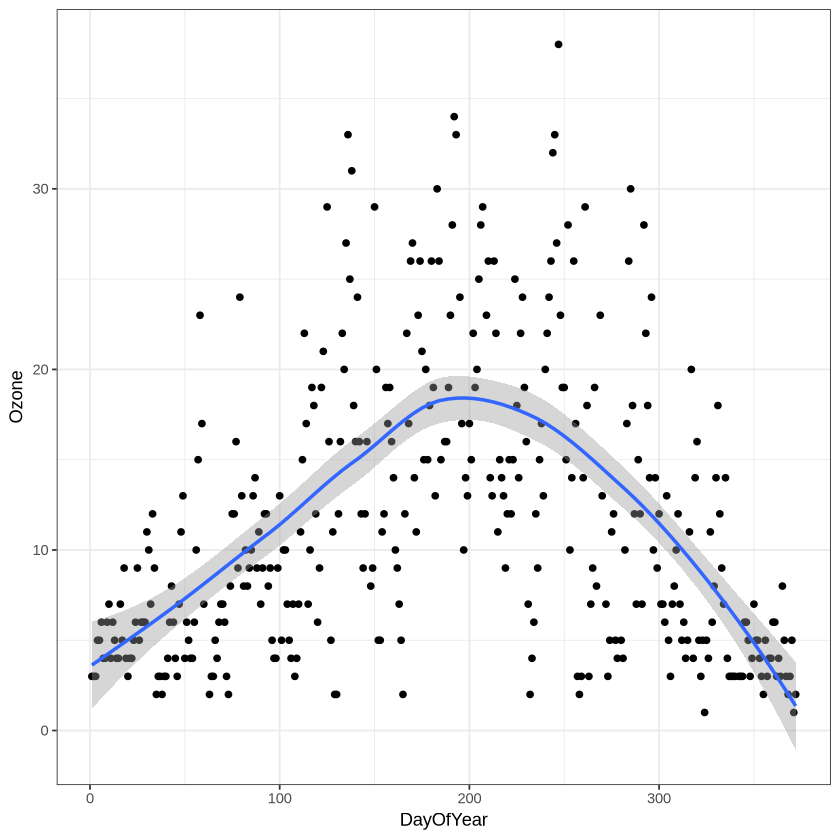

In [69]:
ggplot(ozoneforgam, aes(DayOfYear,Ozone)) + 
geom_point() +
geom_smooth() + 
theme_bw()

ggsave('nonlinear.png')

In [70]:
gamtask<-makeRegrTask(data = ozoneforgam, target = 'Ozone')

imputemethod<-imputeLearner('regr.rpart')

Warning message in makeTask(type = type, data = data, weights = weights, blocking = blocking, :
“Provided data is not a pure data.frame but from class tbl_df, hence it will be converted.”


In [73]:
gamimputewrapper<-makeImputeWrapper(
    'regr.gamboost', 
    classes = list(numeric = imputemethod)
)

In [86]:
gamfeatselcontrol<-makeFeatSelControlSequential(method = 'sfbs')

In [79]:
kfold<-makeResampleDesc('CV', iters=10)

In [88]:
gamfeatselwrapper<-makeFeatSelWrapper(
    learner = gamimputewrapper,
    resampling = kfold,
    control = gamfeatselcontrol
)

In [89]:
#al final agarras el mejor features y lo pasas a validar en total

In [92]:
holdout<-makeResampleDesc('Holdout')

In [94]:
gamcv<-resample(gamfeatselwrapper, gamtask, resampling = holdout)

Resampling: holdout

Measures:             mse       

[FeatSel] Started selecting features for learner 'regr.gamboost.imputed'

With control class: FeatSelControlSequential

Imputation value: Inf

[FeatSel-x] 1: 11111111111 (11 bits)

Warning message in bsplines(mf[[i]], knots = args$knots[[i]]$knots, boundary.knots = args$knots[[i]]$boundary.knots, :
“Some ‘x’ values are beyond ‘boundary.knots’; Linear extrapolation used.”
Warning message in bsplines(mf[[i]], knots = args$knots[[i]]$knots, boundary.knots = args$knots[[i]]$boundary.knots, :
“Some ‘x’ values are beyond ‘boundary.knots’; Linear extrapolation used.”
Warning message in bsplines(mf[[i]], knots = args$knots[[i]]$knots, boundary.knots = args$knots[[i]]$boundary.knots, :
“Some ‘x’ values are beyond ‘boundary.knots’; Linear extrapolation used.”
Warning message in bsplines(mf[[i]], knots = args$knots[[i]]$knots, boundary.knots = args$knots[[i]]$boundary.knots, :
“Some ‘x’ values are beyond ‘boundary.knots’; Linear extrapolation

In [95]:
gamcv

Resample Result
Task: ozoneforgam
Learner: regr.gamboost.imputed.featsel
Aggr perf: mse.test.mean=15.5039211
Runtime: 70.7351

In [96]:
lmcv

Resample Result
Task: ozoneclean
Learner: regr.lm.imputed.featsel
Aggr perf: mse.test.mean=22.4736587
Runtime: 47.4479

In [104]:
parallelStartSocket(cpus = detectCores())
gammodel<-train(gamfeatselwrapper, gamtask)
parallelStop()

Starting parallelization in mode=socket with cpus=16.

[FeatSel] Started selecting features for learner 'regr.gamboost.imputed'

With control class: FeatSelControlSequential

Imputation value: Inf

[FeatSel-x] 1: 11111111111 (11 bits)

Exporting objects to slaves for mode socket: .mlr.slave.options

Mapping in parallel: mode = socket; level = mlr.resample; cpus = 16; elements = 10.

[FeatSel-y] 1: mse.test.mean=15.9126941; time: 0.1 min

Exporting objects to slaves for mode socket: .mlr.slave.options

Mapping in parallel: mode = socket; level = mlr.selectFeatures; cpus = 16; elements = 11.

Exporting objects to slaves for mode socket: .mlr.slave.options

Mapping in parallel: mode = socket; level = mlr.selectFeatures; cpus = 16; elements = 1.

Exporting objects to slaves for mode socket: .mlr.slave.options

Mapping in parallel: mode = socket; level = mlr.selectFeatures; cpus = 16; elements = 10.

Exporting objects to slaves for mode socket: .mlr.slave.options

Mapping in parallel: mode 

In [108]:
gammodeldata<-getLearnerModel(gammodel, more.unwrap = TRUE)

In [127]:
png('gam.png', width = 800, height = 800)
par(mfrow = c(3,3))
plot(gammodeldata, type='l')
plot(gammodeldata$fitted(), resid(gammodeldata))
qqnorm(resid(gammodeldata))
qqline(resid(gammodeldata))
par(mfrow = c(1,1))
dev.off()

agg_record_2069153153 
                    2